## Análisis multivariable y modelo heurístico

### By:
Bryan Escobar Restrepo

### Date:
2026-08-21

### Description:

Tercer y último notebook de `3-analysis`. Combina **tres o más variables a la vez**
para responder lo que el análisis bivariable de `03.2` dejó abierto, y cierra la etapa
con un modelo heurístico evaluado:

1. Cuantificar la multicolinealidad con el VIF, en vez de solo mirar la matriz de
   correlación.
2. Ver si `research` conserva señal propia al **controlar por** `university_rating`, o
   si su efecto era solo el reflejo de la confusión entre ambas.
3. Resolver el problema **manualmente**: construir una heurística que una persona
   podría aplicar a mano, medirla contra un baseline trivial y contra una regresión
   lineal, y decidir si es viable.
4. Identificar las transformaciones necesarias para `4-feat_eng` y los datos
   adicionales que ayudarían al proyecto.

## 📚 Import  libraries

In [1]:
# base libraries for data science
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 50)

print(f"pandas     {pd.__version__}")
print(f"numpy      {np.__version__}")
print(f"seaborn    {sns.__version__}")

pandas     3.0.5
numpy      2.5.2
seaborn    0.13.2


## ⚙️ Configuración

In [2]:
def buscar_raiz_proyecto() -> Path:
    """Sube por el árbol de directorios hasta encontrar la raíz del repositorio."""
    marcadores = (".git", "pyproject.toml")
    actual = Path.cwd().resolve()
    for candidato in (actual, *actual.parents):
        if any((candidato / marcador).exists() for marcador in marcadores):
            return candidato
    return actual


ARCHIVO_ENTRADA = (
    buscar_raiz_proyecto() / "data" / "02_intermediate" / "admisiones_type_fixed.parquet"
)

COLS_NUMERICAS = ["gre_score", "toefl_score", "sop", "lor", "cgpa"]
TARGET = "chance_of_admit"

sns.set_theme(style="whitegrid", palette="deep")
print(f"Entrada: {ARCHIVO_ENTRADA.relative_to(ARCHIVO_ENTRADA.parents[2])}")

Entrada: data/02_intermediate/admisiones_type_fixed.parquet


## 💾 Load data

In [3]:
df = pd.read_parquet(ARCHIVO_ENTRADA)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 471 entries, 0 to 470
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   gre_score          460 non-null    Int64   
 1   toefl_score        452 non-null    Int64   
 2   university_rating  465 non-null    category
 3   sop                455 non-null    Float64 
 4   lor                463 non-null    Float64 
 5   cgpa               469 non-null    Float64 
 6   research           442 non-null    boolean 
 7   chance_of_admit    471 non-null    Float64 
dtypes: Float64(4), Int64(2), boolean(1), category(1)
memory usage: 26.4 KB


## 🌡️ Multicolinealidad: del mapa de calor al VIF

`03.2` mostró que `gre_score`, `toefl_score` y `cgpa` correlacionan entre 0.83 y 0.85
**por pares**. Pero la correlación por pares subestima el problema: una variable puede
ser casi perfectamente predecible a partir de la *combinación* de las otras aunque no
correlacione mucho con ninguna en particular.

El **VIF** (*variance inflation factor*) mide exactamente eso: se regresa cada
predictor contra todos los demás y se calcula `1 / (1 − R²)`. La lectura habitual es
VIF > 5 sospechoso y VIF > 10 problemático.

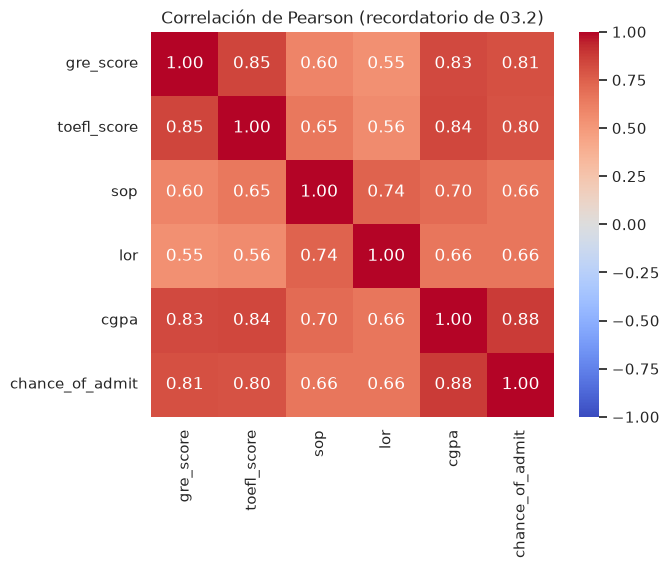

,r2_contra_las_demas,vif
variable,,
cgpa,0.802,5.058
toefl_score,0.769,4.324
gre_score,0.763,4.222
sop,0.641,2.783
lor,0.580,2.380


In [4]:
matriz_correlacion = df[[*COLS_NUMERICAS, TARGET]].astype(float).corr(method="pearson")

_, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación de Pearson (recordatorio de 03.2)")
plt.show()


def calcular_vif(df: pd.DataFrame, columnas: list[str]) -> pd.DataFrame:
    """VIF de cada columna: 1 / (1 - R2) al regresarla contra las demás."""
    datos = df[columnas].dropna().astype(float)
    filas = []
    for columna in columnas:
        otras = [otra for otra in columnas if otra != columna]
        diseno = np.c_[np.ones(len(datos)), datos[otras].to_numpy()]
        coeficientes, *_ = np.linalg.lstsq(diseno, datos[columna].to_numpy(), rcond=None)
        prediccion = diseno @ coeficientes
        ss_residual = ((datos[columna] - prediccion) ** 2).sum()
        ss_total = ((datos[columna] - datos[columna].mean()) ** 2).sum()
        r2 = 1 - ss_residual / ss_total
        filas.append({"variable": columna, "r2_contra_las_demas": r2, "vif": 1 / (1 - r2)})
    return pd.DataFrame(filas).set_index("variable").round(3).sort_values("vif", ascending=False)


calcular_vif(df, COLS_NUMERICAS)

Ningún VIF supera 10, así que la multicolinealidad **no es catastrófica**, pero `cgpa`
(5.06), `toefl_score` (4.32) y `gre_score` (4.22) están en la zona sospechosa: el 80 %
de la varianza de `cgpa` se explica con las otras cuatro variables.

En términos prácticos: un modelo lineal sin regularización sobre las cinco numéricas
dará predicciones razonables pero **coeficientes que no se pueden interpretar** como
"el efecto de subir el GRE en 10 puntos". Para interpretar hace falta Ridge, Lasso o
PCA; para solo predecir, se puede vivir con ello.

## 🔀 Relaciones numéricas coloreadas por `research`

Un `pairplot` de todas las variables numéricas a la vez, coloreado por `research`, para
ver si esa variable separa los datos en algo más que sus medias univariables — es
decir, si crea **subgrupos con estructura propia** o solo desplaza la nube.

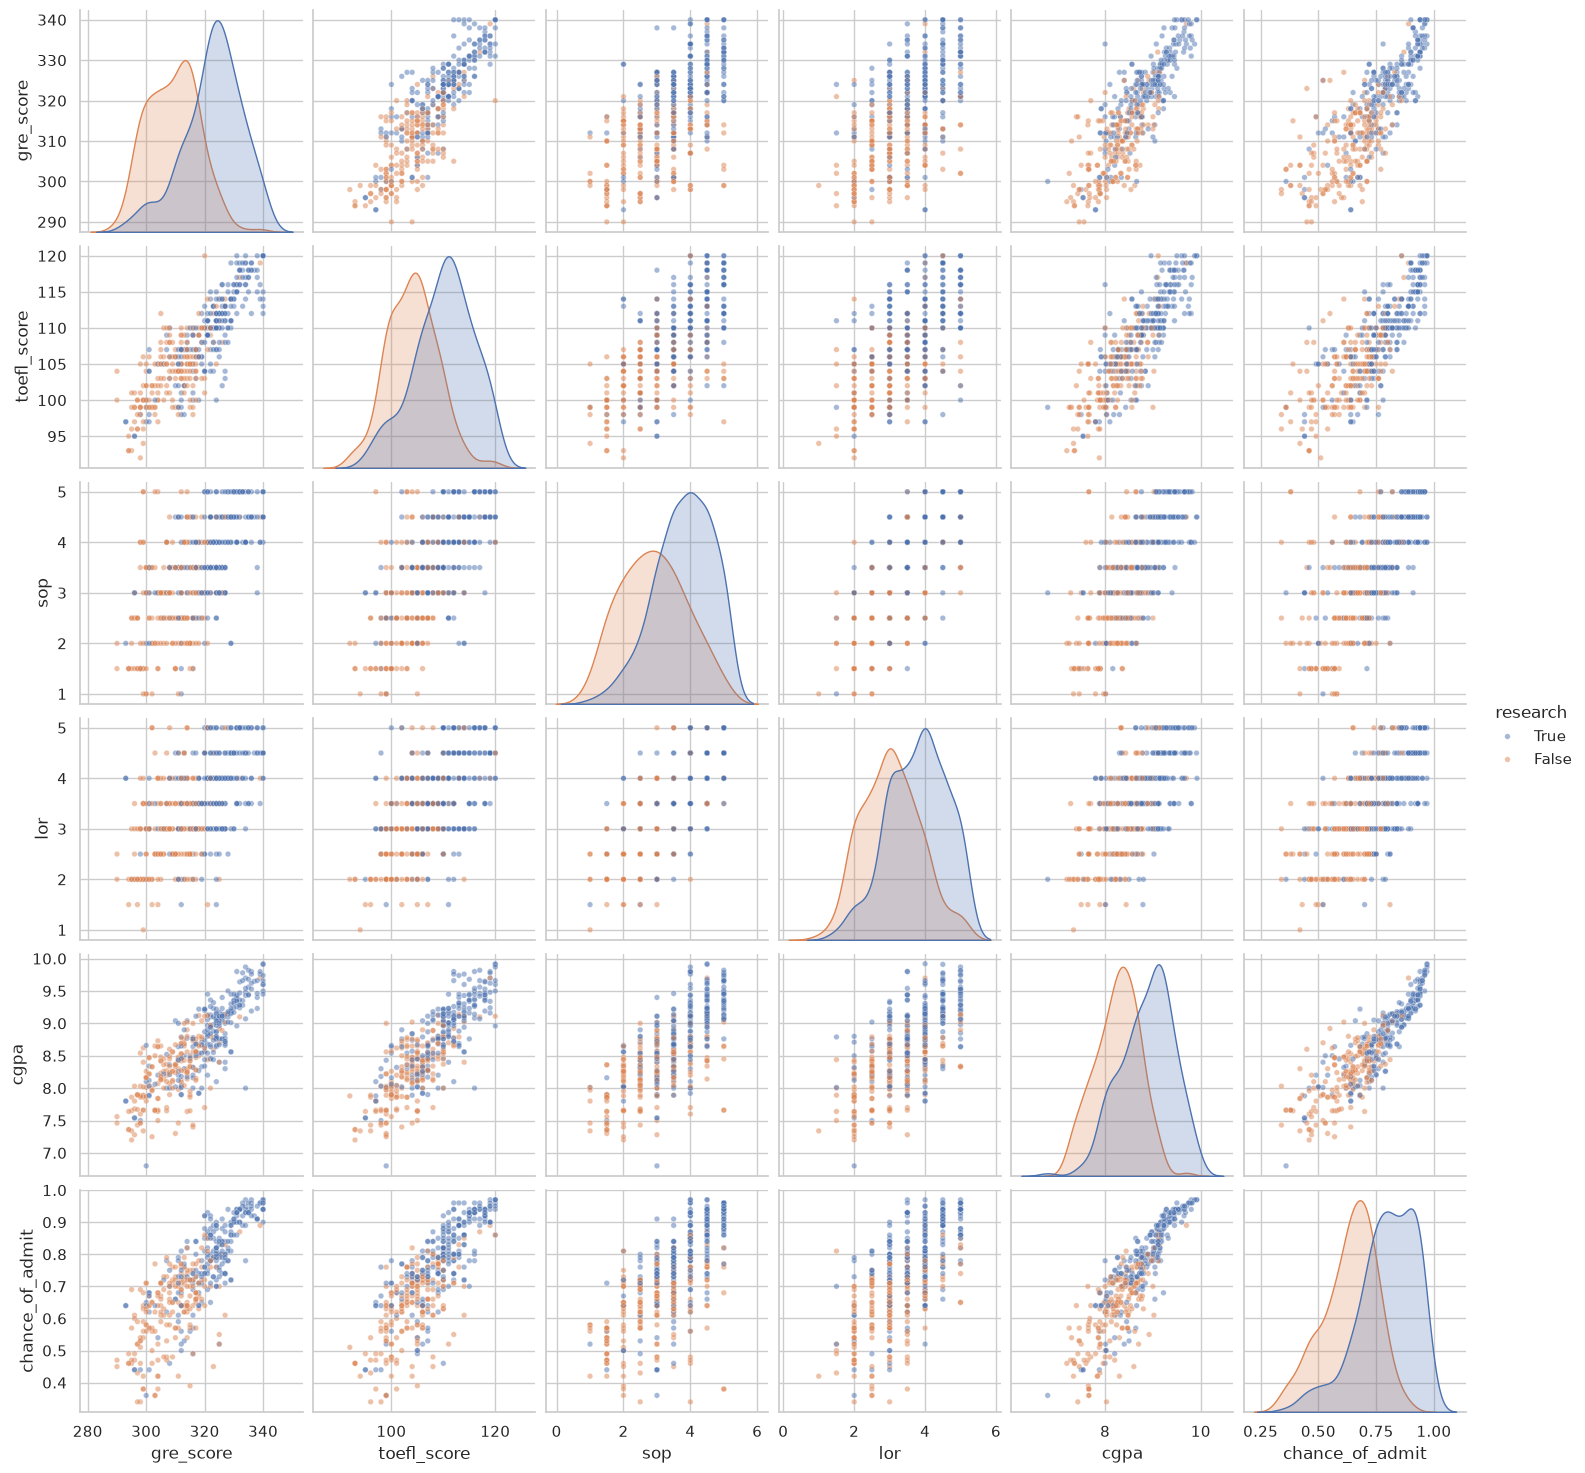

In [5]:
subset_pairplot = df[[*COLS_NUMERICAS, TARGET, "research"]].dropna(subset=["research"]).copy()
subset_pairplot["research"] = subset_pairplot["research"].astype(str)

sns.pairplot(subset_pairplot, hue="research", diag_kind="kde", plot_kws={"alpha": 0.5, "s": 16})
plt.show()

No aparecen dos nubes separadas en ningún par de variables: los puntos de
`research = True` están sistemáticamente desplazados hacia valores más altos en casi
todos los ejes, pero **se superponen ampliamente** con los de `research = False`.

La lectura es importante para el modelado: `research` **desplaza medias, no crea
subgrupos estructuralmente distintos**. No hay motivo para entrenar dos modelos
separados (uno por valor de `research`); basta con incluirla como una variable más.

## 🧩 Interacción: target según `university_rating` × `research`

Esta es la pregunta que quedó abierta en `03.2`. Allí se vio que `research` está
fuertemente ligada a `university_rating` (χ² = 80.9): en las universidades de rating 5
el 84 % tiene experiencia en investigación, frente al 18 % en las de rating 1.

Entonces, ¿la brecha de +0.16 en el target asociada a `research` es señal propia, o solo
el reflejo de que quienes hacen investigación vienen de universidades mejor calificadas?
La forma de responderlo es **controlar por** `university_rating`: mirar el efecto de
`research` *dentro de cada nivel*.

                             mean  count
university_rating research              
1                 False     0.538     23
                  True       0.58      5
2                 False     0.613     79
                  True      0.661     37
3                 False      0.67     71
                  True      0.742     75
4                 False     0.665     18
                  True      0.849     61
5                 False     0.733     11
                  True       0.91     59

research           False   True  brecha
university_rating                      
1                  0.538   0.58   0.042
2                  0.613  0.661   0.049
3                   0.67  0.742   0.072
4                  0.665  0.849   0.184
5                  0.733   0.91   0.177


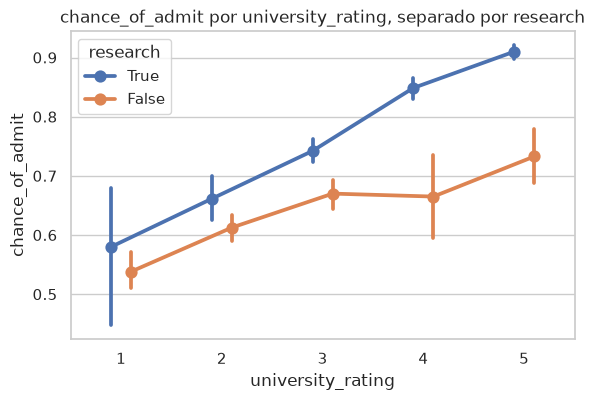

In [6]:
tabla_interaccion = (
    df.groupby(["university_rating", "research"], observed=True)[TARGET]
    .agg(["mean", "count"])
    .round(3)
)
print(tabla_interaccion.to_string())

medias = df.pivot_table(
    index="university_rating", columns="research", values=TARGET, aggfunc="mean", observed=True
)
medias["brecha"] = (medias[True] - medias[False]).round(3)
print()
print(medias.round(3).to_string())

# seaborn no admite un hue booleano con nulos: se pasa como texto y sin nulos
datos_interaccion = df.dropna(subset=["research"]).copy()
datos_interaccion["research"] = datos_interaccion["research"].astype(str)

_, ax = plt.subplots(figsize=(6.5, 4))
sns.pointplot(
    data=datos_interaccion,
    x="university_rating",
    y=TARGET,
    hue="research",
    order=sorted(datos_interaccion["university_rating"].dropna().unique()),
    dodge=0.2,
    ax=ax,
)
ax.set_title(f"{TARGET} por university_rating, separado por research")
plt.show()

**El efecto no desaparece:** dentro de cada nivel de `university_rating`, tener
`research = True` sigue asociado a una media más alta del target. Pero la brecha
**crece con el nivel**:

| `university_rating` | sin research | con research | brecha | n con research |
|---|---|---|---|---|
| 1 | 0.538 | 0.580 | +0.042 | 5 |
| 2 | 0.613 | 0.661 | +0.049 | 37 |
| 3 | 0.670 | 0.742 | +0.072 | 75 |
| 4 | 0.665 | 0.849 | +0.184 | 61 |
| 5 | 0.733 | 0.910 | +0.177 | 59 |

Es decir, **hay interacción**: el valor de la experiencia en investigación no es
constante, se multiplica en las universidades mejor calificadas. Un modelo lineal sin
término de interacción no puede capturar esto; un modelo de árboles sí, de forma
automática.

Dos advertencias honestas sobre esta tabla: en el nivel 1 hay solo **5 casos** con
`research = True`, así que esa brecha de +0.042 no es fiable; y esto sigue siendo
asociación, no causalidad — controlar por una variable no controla por las otras cinco.

## 🧮 Modelo heurístico: resolver el problema manualmente

Antes de entrenar cualquier modelo, la pregunta obligada es **hasta dónde llega una
regla simple que una persona podría aplicar a mano**. Sirve como piso de referencia: si
un modelo entrenado no supera claramente esta heurística, no vale la complejidad que
añade.

La regla propuesta es la más simple posible: normalizar cada variable a [0, 1] **según
su dominio documentado** (no según el mínimo y máximo de la muestra, para que la regla
siga siendo válida con datos nuevos) y promediarlas sin ponderar.

Se compara contra tres referencias:

- **Baseline trivial:** predecir siempre la media del target.
- **Heurística reducida:** solo las tres variables más asociadas al target.
- **Regresión lineal ajustada:** el techo razonable de un modelo simple, para saber
  cuánto se está dejando sobre la mesa.

In [7]:
COLS_HEURISTICA = [*COLS_NUMERICAS, "university_rating", "research"]
df_heur = df.dropna(subset=[*COLS_HEURISTICA, TARGET]).copy()
print(f"Filas sin nulos en las columnas relevantes: {len(df_heur)} de {len(df)}")

# normalizacion a [0, 1] usando el dominio documentado, no el rango observado
normalizado = pd.DataFrame(index=df_heur.index)
normalizado["gre_score"] = (df_heur["gre_score"].astype(float) - 260) / (340 - 260)
normalizado["toefl_score"] = df_heur["toefl_score"].astype(float) / 120
normalizado["university_rating"] = (df_heur["university_rating"].astype(int) - 1) / 4
normalizado["sop"] = (df_heur["sop"].astype(float) - 1) / 4
normalizado["lor"] = (df_heur["lor"].astype(float) - 1) / 4
normalizado["cgpa"] = df_heur["cgpa"].astype(float) / 10
normalizado["research"] = df_heur["research"].astype(float)

y = df_heur[TARGET].astype(float)


def mae(y_real: pd.Series, y_predicho: pd.Series) -> float:
    """Error absoluto medio."""
    return float(np.mean(np.abs(np.asarray(y_real) - np.asarray(y_predicho))))


def rmse(y_real: pd.Series, y_predicho: pd.Series) -> float:
    """Raíz del error cuadrático medio."""
    return float(np.sqrt(np.mean((np.asarray(y_real) - np.asarray(y_predicho)) ** 2)))


heuristica = normalizado.mean(axis=1)
heuristica_reducida = normalizado[["cgpa", "gre_score", "toefl_score"]].mean(axis=1)
baseline = pd.Series(y.mean(), index=y.index)

candidatos = {
    "heuristica: promedio de las 7 variables": heuristica,
    "heuristica reducida: cgpa+gre+toefl": heuristica_reducida,
    "solo cgpa normalizado": normalizado["cgpa"],
    "baseline: media del target": baseline,
}
comparacion = pd.DataFrame(
    {
        "MAE": [mae(y, p) for p in candidatos.values()],
        "RMSE": [rmse(y, p) for p in candidatos.values()],
        "spearman": [
            y.corr(p, method="spearman") if p.std() > 0 else float("nan")
            for p in candidatos.values()
        ],
    },
    index=list(candidatos),
)
comparacion.round(4)

Filas sin nulos en las columnas relevantes: 400 de 471


,MAE,RMSE,spearman
heuristica: promedio de las 7 variables,0.0855,0.1089,0.8458
heuristica reducida: cgpa+gre+toefl,0.0993,0.1286,0.8694
solo cgpa normalizado,0.1357,0.1655,0.8784
baseline: media del target,0.1144,0.1424,NaN


**Lectura:** la heurística de 7 variables logra **MAE 0.0855 frente a 0.1144 del
baseline**, una mejora del 25 % con una regla que cabe en una línea. Su Spearman con el
target es 0.846, así que también **ordena** bien a los aspirantes, que es el uso real
del producto.

El detalle interesante está en la comparación entre candidatos: la heurística reducida
(solo `cgpa`, `gre_score`, `toefl_score`) tiene **peor MAE** (0.099) pero **mejor
Spearman** (0.869), y `cgpa` sola es la que mejor ordena de todas (0.878) pese a tener
el peor MAE (0.136) de las heurísticas.

Esa aparente contradicción no lo es: MAE mide el acierto del *valor*, Spearman el del
*orden*. Promediar siete variables acerca el número al target, pero diluye la señal más
fuerte a la hora de ordenar. **La elección depende de qué se le muestra al usuario:** un
número o un ranking.

### El problema de escala de la heurística cruda

La heurística promedia variables normalizadas, así que produce valores en [0, 1] — pero
nada garantiza que esa escala coincida con la del target. Ajustar dos números
(`a + b × heurística`) corrige el desfase sin cambiar el orden de los aspirantes.

Esto ya no es "aplicable a mano" en sentido estricto, pero sigue siendo una regla que
cabe en una línea, y permite medirla en condiciones justas contra una regresión lineal.
Se usa una partición **train/test** para no evaluar sobre los mismos datos con los que
se calibró.

In [8]:
PROPORCION_TRAIN = 0.75
SEMILLA = 42

generador = np.random.default_rng(SEMILLA)
orden = generador.permutation(len(df_heur))
corte = int(PROPORCION_TRAIN * len(df_heur))
idx_train, idx_test = orden[:corte], orden[corte:]

y_np = y.to_numpy()
y_train, y_test = y_np[idx_train], y_np[idx_test]
print(f"train: {len(idx_train)} filas   test: {len(idx_test)} filas")


def ajustar_lineal(matriz: np.ndarray, objetivo: np.ndarray) -> np.ndarray:
    """Mínimos cuadrados con término independiente."""
    diseno = np.c_[np.ones(len(matriz)), matriz]
    coeficientes, *_ = np.linalg.lstsq(diseno, objetivo, rcond=None)
    return coeficientes


def predecir_lineal(matriz: np.ndarray, coeficientes: np.ndarray) -> np.ndarray:
    return np.c_[np.ones(len(matriz)), matriz] @ coeficientes


heuristica_np = heuristica.to_numpy().reshape(-1, 1)
coef_calibracion = ajustar_lineal(heuristica_np[idx_train], y_train)
pred_calibrada = predecir_lineal(heuristica_np[idx_test], coef_calibracion)

matriz_completa = normalizado.to_numpy()
coef_regresion = ajustar_lineal(matriz_completa[idx_train], y_train)
pred_regresion = predecir_lineal(matriz_completa[idx_test], coef_regresion)

resultados_test = pd.DataFrame(
    {
        "MAE": [
            mae(y_test, np.full(len(y_test), y_train.mean())),
            mae(y_test, heuristica_np[idx_test].ravel()),
            mae(y_test, pred_calibrada),
            mae(y_test, pred_regresion),
        ],
        "RMSE": [
            rmse(y_test, np.full(len(y_test), y_train.mean())),
            rmse(y_test, heuristica_np[idx_test].ravel()),
            rmse(y_test, pred_calibrada),
            rmse(y_test, pred_regresion),
        ],
    },
    index=[
        "baseline: media del target",
        "heuristica cruda (7 variables)",
        "heuristica recalibrada (a + b*h)",
        "regresion lineal (7 variables)",
    ],
)
print(f"\ncalibracion ajustada: a = {coef_calibracion[0]:.3f}, b = {coef_calibracion[1]:.3f}")
resultados_test.round(4)

train: 300 filas   test: 100 filas

calibracion ajustada: a = 0.252, b = 0.698


,MAE,RMSE
baseline: media del target,0.1048,0.1283
heuristica cruda (7 variables),0.0913,0.1149
heuristica recalibrada (a + b*h),0.0627,0.0813
regresion lineal (7 variables),0.0448,0.0630


Sobre el conjunto de prueba, que ninguna de las reglas vio al calibrarse:

| Modelo | MAE | Mejora vs. baseline |
|---|---|---|
| Baseline (media del target) | 0.1048 | — |
| Heurística cruda | 0.0913 | 13 % |
| Heurística recalibrada (`0.252 + 0.698 × h`) | 0.0627 | **40 %** |
| Regresión lineal (7 variables) | 0.0448 | **57 %** |

Dos conclusiones:

1. **La recalibración vale mucho.** Ajustar dos números baja el MAE de 0.091 a 0.063.
   La heurística cruda estaba sistemáticamente desplazada, no mal ordenada.
2. **Un modelo entrenado supera claramente a la heurística**, incluso el más simple de
   todos: la regresión lineal reduce otro 29 % el error de la heurística recalibrada.
   Ese es el argumento cuantitativo para justificar la etapa `5-models`.

### La heurística en el uso real: "segura / probable / ambiciosa"

El objetivo de negocio planteado en `notebooks/1-data` no es acertar el valor exacto,
sino **clasificar cada universidad en tres cestas** para que el aspirante arme su lista.
Esa es la prueba que de verdad importa: ¿la heurística pone a cada aspirante en la
cesta correcta?

Se parte el target en tercios (ambiciosa / probable / segura) y se compara con los
tercios que produce la heurística.

Acierto de cesta      : 69.5%  (azar = 33.3%)
Errores de dos cestas : 3 de 400 (0.8%)


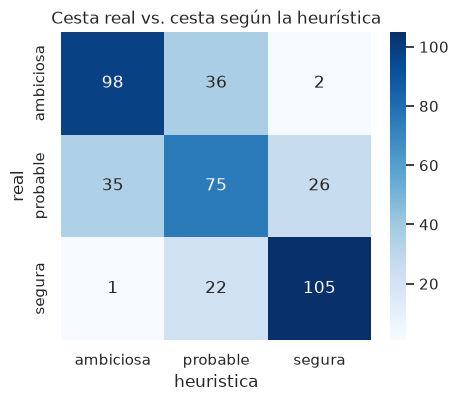

heuristica,ambiciosa,probable,segura
real,,,
ambiciosa,98,36,2
probable,35,75,26
segura,1,22,105


In [9]:
ETIQUETAS = ["ambiciosa", "probable", "segura"]


def a_terciles(serie: pd.Series) -> pd.Series:
    """Parte una serie en tres cestas por sus propios terciles."""
    cortes = serie.quantile([1 / 3, 2 / 3]).tolist()
    return pd.cut(serie, [-np.inf, *cortes, np.inf], labels=ETIQUETAS)


cesta_real = a_terciles(y)
cesta_heuristica = a_terciles(heuristica)

acierto = float((cesta_real == cesta_heuristica).mean())
matriz_confusion = pd.crosstab(
    cesta_real, cesta_heuristica, rownames=["real"], colnames=["heuristica"]
)

print(f"Acierto de cesta      : {acierto:.1%}  (azar = 33.3%)")
error_grave = int(
    matriz_confusion.loc["ambiciosa", "segura"] + matriz_confusion.loc["segura", "ambiciosa"]
)
print(f"Errores de dos cestas : {error_grave} de {len(y)} ({error_grave / len(y):.1%})")

_, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(matriz_confusion, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Cesta real vs. cesta según la heurística")
plt.show()
matriz_confusion

**69.5 % de acierto** frente al 33.3 % del azar, y —lo más importante— solo **3 casos de
400 (0.8 %)** caen en el error grave: llamar "segura" a una universidad que era
"ambiciosa" o al revés. Los fallos son casi siempre de una cesta adyacente, que es el
tipo de error que un usuario puede tolerar.

Este resultado es el que sostiene la respuesta a la pregunta de la tarea.

### ✅ Veredicto: ¿es viable un modelo heurístico?

**Sí, es viable como primera versión del producto, y con una condición.**

A favor:

- Con la recalibración de dos parámetros alcanza **MAE 0.063** en datos no vistos, un
  40 % mejor que el baseline. En la escala del problema eso es equivocarse ~6 puntos
  porcentuales de probabilidad de admisión.
- Acierta la cesta (*segura / probable / ambiciosa*) el **69.5 %** de las veces y casi
  nunca se equivoca en dos cestas (0.8 %), que es el único error con consecuencias
  reales para el aspirante.
- Es **totalmente transparente**: el usuario puede recalcularla a mano y entender por
  qué le salió ese número, algo valioso en un producto de orientación que no debe
  parecer una caja negra.
- No necesita entrenamiento, ni versionado de modelo, ni infraestructura: es aritmética.

En contra, y esta es la condición:

- La regresión lineal más simple ya la supera con **MAE 0.045** (29 % mejor). El costo
  de esa mejora es bajísimo, así que la heurística **no debería ser el destino final**.
- No captura la interacción `university_rating` × `research` documentada arriba.
- Ponderar todas las variables por igual es indefendible con los datos a la vista:
  `cgpa` se asocia al target con 0.88 y `research` con 0.55, y aun así pesan lo mismo.

**Recomendación:** usar la heurística recalibrada como *fallback* y como piso de
referencia (`MAE ≤ 0.063` y acierto de cesta ≥ 69.5 % es lo mínimo que debe superar
cualquier modelo de `5-models`), y no como el modelo del producto.

## 🔧 Transformaciones identificadas para `4-feat_eng`

- **Escalado:** los predictores viven en escalas muy distintas (`gre_score` 290-340,
  `toefl_score` 92-120, `cgpa` 6.8-9.9, `sop`/`lor` 1-5). Todo modelo basado en
  distancias o con regularización L1/L2 necesita estandarizarlos antes; la heurística de
  este notebook ya lo hace a mano con el dominio documentado.
- **Multicolinealidad:** VIF de 4.2 a 5.1 en `gre_score`, `toefl_score` y `cgpa`.
  Opciones: quedarse con `cgpa`, aplicar PCA a las tres, o usar Ridge/Lasso.
- **Término de interacción:** `university_rating` × `research` tiene efecto real y
  creciente. Si se usa un modelo lineal, hay que crear la variable de interacción
  explícitamente; un modelo de árboles la captura solo.
- **`university_rating`:** ya es `category` ordinal. Se puede usar como entero ordinal
  en árboles, o con *one-hot* si el modelo no respeta el orden.
- **`research`:** booleana, castear a 0/1 para cualquier modelo que no maneje `boolean`
  de forma nativa.
- **Nulos:** `research` (6.16 %) necesita estrategia propia por ser binaria (moda o
  modelo, nunca la media); el resto de columnas está por debajo del 4.1 % y admite
  imputación por mediana, o un modelo que tolere `NA` de forma nativa
  (`HistGradientBoosting`, LightGBM).
- **Sin transformación de forma:** ninguna variable es logarítmica ni fuertemente
  asimétrica (`03.1`), así que no se justifica log ni Box-Cox.
- **No hace falta tratar los atípicos:** los 4 valores fuera del IQR están dentro del
  dominio válido y son la cola real de la distribución.

## ➕ Datos adicionales que serían útiles

- **Nombre o ranking real de la universidad**, en vez de un `university_rating` anónimo
  de 1 a 5: permitiría enlazar con rankings públicos y con la tasa de admisión histórica
  real de cada programa, que hoy es la variable que más falta hace.
- **Programa y área de estudio** al que se postula: la probabilidad de admisión a
  Ingeniería y a Humanidades en la misma universidad no es comparable.
- **Año de postulación**, para detectar tendencias y poder validar el modelo en el
  tiempo (hoy no hay ninguna columna temporal).
- **Experiencia laboral y publicaciones**, más allá del indicador binario `research`.
- **Financiamiento o beca solicitada**, que en muchos programas cambia el umbral de
  admisión.
- **El resultado real de la postulación** (admitido / rechazado). El target actual es
  una probabilidad estimada, no un hecho observado: cualquier sesgo de quien la estimó
  está dentro de los datos y el modelo lo va a reproducir.

## 📊 Analysis of Results and Conclusions

- **La multicolinealidad es moderada, no crítica** (VIF máximo 5.06). Impide interpretar
  los coeficientes de un modelo lineal, pero no impide predecir con él.
- **`research` conserva señal propia** dentro de cada nivel de `university_rating`: no
  era un artefacto de la confusión detectada en `03.2`. Además **interactúa** con esa
  variable — la brecha pasa de +0.04 en el rating 1 a +0.18 en el 4 y el 5.
- **`research` no crea subgrupos:** el `pairplot` muestra desplazamiento de medias, no
  nubes separadas. No hay razón para entrenar modelos distintos por grupo.
- **Una heurística de una línea es sorprendentemente competitiva**: 25 % mejor que el
  baseline sin calibrar, 40 % con dos parámetros ajustados, y 69.5 % de acierto en la
  clasificación por cestas que es el uso real del producto.
- **Pero un modelo entrenado la supera con claridad** (MAE 0.045 vs. 0.063), y a un
  costo mínimo. La heurística es el piso, no el techo.
- **Tensión MAE vs. Spearman:** ninguna heurística gana en ambas métricas a la vez.
  Antes de `5-models` hay que decidir cuál de las dos optimiza el producto — y esa es
  una decisión de negocio, no técnica.

## 💡 Proposals and Ideas

- Fijar como criterio de aceptación de `5-models`: **MAE ≤ 0.063** y **acierto de cesta
  ≥ 69.5 %** sobre el mismo conjunto de prueba. Un modelo que no lo supere no justifica
  su complejidad.
- Empezar `5-models` por una regresión lineal regularizada (Ridge) como referencia
  interpretable, y comparar contra un modelo de árboles que capture la interacción
  `university_rating` × `research` sin especificarla.
- Implementar la heurística recalibrada en el producto como *fallback* para cuando falten
  datos del aspirante: degrada con elegancia, mientras que un modelo entrenado
  necesitaría imputar.
- Levantar el dato de resultado real de admisión: mientras el target sea una estimación
  subjetiva, el techo del proyecto lo pone la calidad de esa estimación, no el modelo.

## 📖 References

- Análisis multivariable, Jose R. Zapata:
  <https://joserzapata.github.io/post/ciencia-datos-proyecto-python/3-analysis/>
- `seaborn.pairplot`: <https://seaborn.pydata.org/generated/seaborn.pairplot.html>
- *Variance inflation factor*: <https://en.wikipedia.org/wiki/Variance_inflation_factor>